In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install transformers openpyxl scikit-learn

In [3]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from collections import Counter

In [4]:
path = "/content/drive/MyDrive/dataset/dataset_clean.xlsx"
df = pd.read_excel(path)

print(df.head())
print(df['Hoax'].value_counts())
print("Total data:", len(df))

                                              Narasi  Hoax
0  uskup agung jakarta kardinal mgr. ignatius suh...     0
1  mike tysonmenyebut legenda tinju dunia muhamma...     0
2  pesta diskon bertajuktransmart full day saleke...     0
3  kejaksaan agung kejagung menyebut jumlah uang ...     0
4  mohamed salahberpeluang menciptakan rekor unik...     0
Hoax
0    12643
1    11942
Name: count, dtype: int64
Total data: 24585


In [5]:
X = df['Narasi'].tolist()
y = df['Hoax'].tolist()

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [7]:
print("Train:", Counter(y_train))
print("Val  :", Counter(y_val))
print("Test :", Counter(y_test))

Train: Counter({0: 8850, 1: 8359})
Val  : Counter({0: 1896, 1: 1792})
Test : Counter({0: 1897, 1: 1791})


In [8]:
def sanitize_text(text_list):
    clean_text = []
    for t in text_list:
        if isinstance(t, str):
            clean_text.append(t)
        else:
            clean_text.append("")
    return clean_text

X_train = sanitize_text(X_train)
X_val   = sanitize_text(X_val)
X_test  = sanitize_text(X_test)

In [9]:
tokenizer = AutoTokenizer.from_pretrained(
    "indobenchmark/indobert-base-p1"
)

def tokenize(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

train_enc = tokenize(X_train)
val_enc   = tokenize(X_val)
test_enc  = tokenize(X_test)

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [10]:
class HoaxDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_ds = HoaxDataset(train_enc, y_train)
val_ds   = HoaxDataset(val_enc, y_val)
test_ds  = HoaxDataset(test_enc, y_test)

In [11]:
class IndoBERT_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained(
            "indobenchmark/indobert-base-p1"
        )

        self.conv1 = nn.Conv1d(768, 128, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(768, 128, kernel_size=4, padding=2)
        self.conv3 = nn.Conv1d(768, 128, kernel_size=5, padding=2)

        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(128 * 3, 2)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        x = outputs.last_hidden_state
        x = x.permute(0, 2, 1)

        c1 = self.pool(self.relu(self.conv1(x))).squeeze(2)
        c2 = self.pool(self.relu(self.conv2(x))).squeeze(2)
        c3 = self.pool(self.relu(self.conv3(x))).squeeze(2)

        x = torch.cat([c1, c2, c3], dim=1)
        return self.fc(x)

In [12]:
model = IndoBERT_CNN()

for param in model.bert.embeddings.parameters():
    param.requires_grad = False

# freeze encoder layer 0–5
for layer in model.bert.encoder.layer[:6]:
    for param in layer.parameters():
        param.requires_grad = False

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  498MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  498MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-5
)

criterion = nn.CrossEntropyLoss()

train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=64,
    pin_memory=True
)

In [14]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention = batch['attention_mask'].to(device)
            labels    = batch['labels'].to(device)

            outputs = model(input_ids, attention)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

    return total_loss / len(loader)

In [15]:
best_val_loss = float('inf')
epochs = 5

# Menyimpan nilai loss setiap epoch
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Menghitung rata-rata training loss
    train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    # Menghitung rata-rata validation loss
    val_loss = val_loss / len(val_loader)

    # Menyimpan loss setiap epoch
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/dataset/indobert_cnn.pt"
        )

        print("Model terbaik disimpan")

Epoch 1/5 | Train Loss: 0.0507 | Val Loss: 0.0205
Model terbaik disimpan
Epoch 2/5 | Train Loss: 0.0091 | Val Loss: 0.0098
Model terbaik disimpan
Epoch 3/5 | Train Loss: 0.0036 | Val Loss: 0.0134
Epoch 4/5 | Train Loss: 0.0042 | Val Loss: 0.0134
Epoch 5/5 | Train Loss: 0.0014 | Val Loss: 0.0166


**EVALUASI**

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import numpy as np

In [17]:
test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False,
    pin_memory=True
)

In [18]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention = batch['attention_mask'].to(device)
        labels    = batch['labels'].to(device)

        outputs = model(input_ids, attention)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

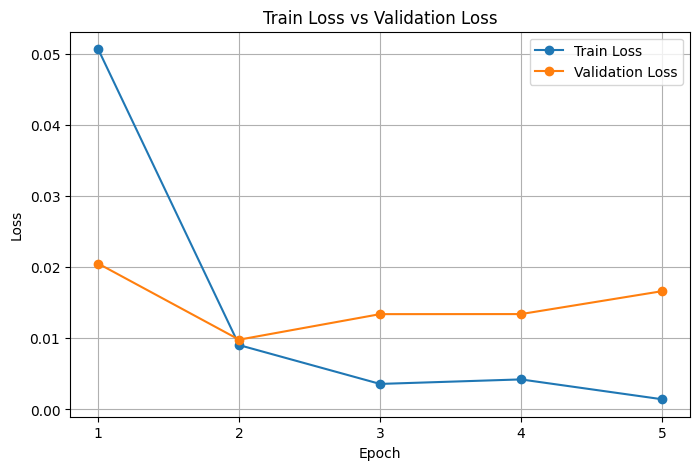

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    train_losses,
    marker='o',
    label='Train Loss'
)

plt.plot(
    range(1, epochs + 1),
    val_losses,
    marker='o',
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Loss vs Validation Loss")
plt.xticks(range(1, epochs + 1))
plt.legend()
plt.grid(True)

plt.show()

In [20]:
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)

print("Akurasi  :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Akurasi  : 0.9964750542299349
Precision: 0.9988776655443322
Recall   : 0.993858179787828
F1-score : 0.9963616008956059


In [21]:
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1895    2]
 [  11 1780]]


In [22]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Fakta", "Hoaks"]
    )
)

              precision    recall  f1-score   support

       Fakta       0.99      1.00      1.00      1897
       Hoaks       1.00      0.99      1.00      1791

    accuracy                           1.00      3688
   macro avg       1.00      1.00      1.00      3688
weighted avg       1.00      1.00      1.00      3688



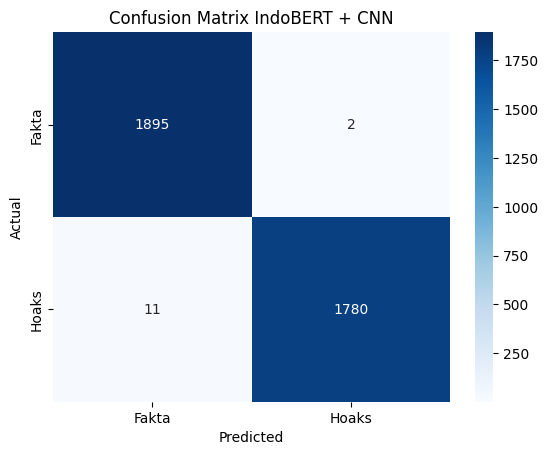

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fakta", "Hoaks"],
    yticklabels=["Fakta", "Hoaks"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix IndoBERT + CNN")
plt.show()

In [26]:
import pandas as pd

hasil_testing = pd.DataFrame({
    "Narasi": X_test,
    "Prediksi": ["Hoaks" if p == 1 else "Fakta" for p in y_pred],
    "Label Sebenarnya": ["Hoaks" if y == 1 else "Fakta" for y in y_true]
})

output_path = "/content/drive/MyDrive/dataset/hasil_testing_indobert_cnn.csv"

hasil_testing.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("Seluruh hasil klasifikasi data testing:")
print(hasil_testing.to_string(index=False))

print("\nFile CSV berhasil disimpan di:")
print(output_path)

Output hidden; open in https://colab.research.google.com to view.

In [27]:
# Mengambil 6 data pertama dari data testing

model.eval()

with torch.no_grad():
    input_ids = test_enc["input_ids"][:6].to(device)
    attention_mask = test_enc["attention_mask"][:6].to(device)

    outputs = model.bert(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    embeddings = outputs.last_hidden_state.cpu()
    input_ids_cpu = input_ids.cpu()


for i in range(6):

    # Mengubah input IDs menjadi token
    tokens = tokenizer.convert_ids_to_tokens(
        input_ids_cpu[i]
    )

    # Mengambil 7 nilai embedding pertama
    embedding_7 = embeddings[i][0][:7].numpy()

    print("=" * 100)
    print(f"DATA TESTING KE-{i+1}")
    print("=" * 100)

    print("\nNarasi:")
    print(X_test[i])

    print("\nTokens:")
    print(tokens)

    print("\nInput IDs:")
    print(input_ids_cpu[i].tolist())

    print("\nEmbedding:")
    print(
        "[" +
        ", ".join(f"{value:.6f}" for value in embedding_7) +
        ", ...]"
    )


DATA TESTING KE-1

Narasi:
there are only two projects in history that have cost more than the track trace app the iss 72bn and the entire us road network 82bn . so there we we sic have it at 37 billion the third most expensive thing we ve ever spaffed money on is a broken version of pokemon go. hanya ada dua proyek dalam sejarah yang menelan biaya lebih besar daripada aplikasi track trace iss 72 miliar dan seluruh jaringan jalan raya as 82 miliar . jadi begitulah yang kami dapatkan dengan harga 37 miliar barang termahal ketiga yang pernah kami belanjakan adalah versi rusak dari pokemon go.

Tokens:
['[CLS]', 'there', 'are', 'only', 'two', 'project', '##s', 'in', 'history', 'that', 'have', 'cost', 'more', 'than', 'the', 'track', 'tra', '##ce', 'app', 'the', 'is', '##s', '72', '##bn', 'and', 'the', 'ent', '##ire', 'us', 'road', 'network', '82', '##bn', '.', 'so', 'there', 'we', 'we', 'sic', 'have', 'it', 'at', '37', 'bill', '##ion', 'the', 'thir', '##d', 'most', 'exp', '##ensi', '##ve',